![Quantyma Research](logo.png)

**Title:** A Robust Anomaly Detection in Industrial Gearbox Systems Using Acoustic Signals under High Noise Conditions.  
**Author:** Bruno Priantti  
**Institution:** Quantyma Research  
**Date:** May 2026  
**License:** MIT License  

**Content:**  
This notebook implements the experimental framework for evaluating the robustness of an unsupervised anomaly detection pipeline based on Principal Component Analysis (PCA) under high-noise industrial conditions.

The proposed methodology is validated using acoustic recordings of rotating machinery, simulating realistic gearbox operating environments with significant background noise and mechanical variability. A multi-domain signal processing pipeline is employed, including spectral analysis, envelope extraction, and statistical feature engineering, to construct a physically interpretable feature space suitable for subspace-based fault detection.

The system is evaluated under varying acoustic noise conditions to assess its ability to preserve discriminative structure between normal and anomalous operating states.

### imports:

In [1]:
import numpy as np
import pandas as pd

from pathlib import Path
from methods import *

### params:

In [2]:
dataset="data"
sample_rate = 16000
low = 4000
high = 7000
cutoff = 100
n_components=0.90

### load dataset:

In [3]:
train_path = Path(f"../{dataset}") / 'train'
test_path = Path(f"../{dataset}") / 'test'

train_audio_dict = load_all_audio_files_for_file_set(set_path = train_path, sr = sample_rate)
test_audio_dict = load_all_audio_files_for_file_set(set_path = test_path, sr = sample_rate)

### exploratory signal analisys:

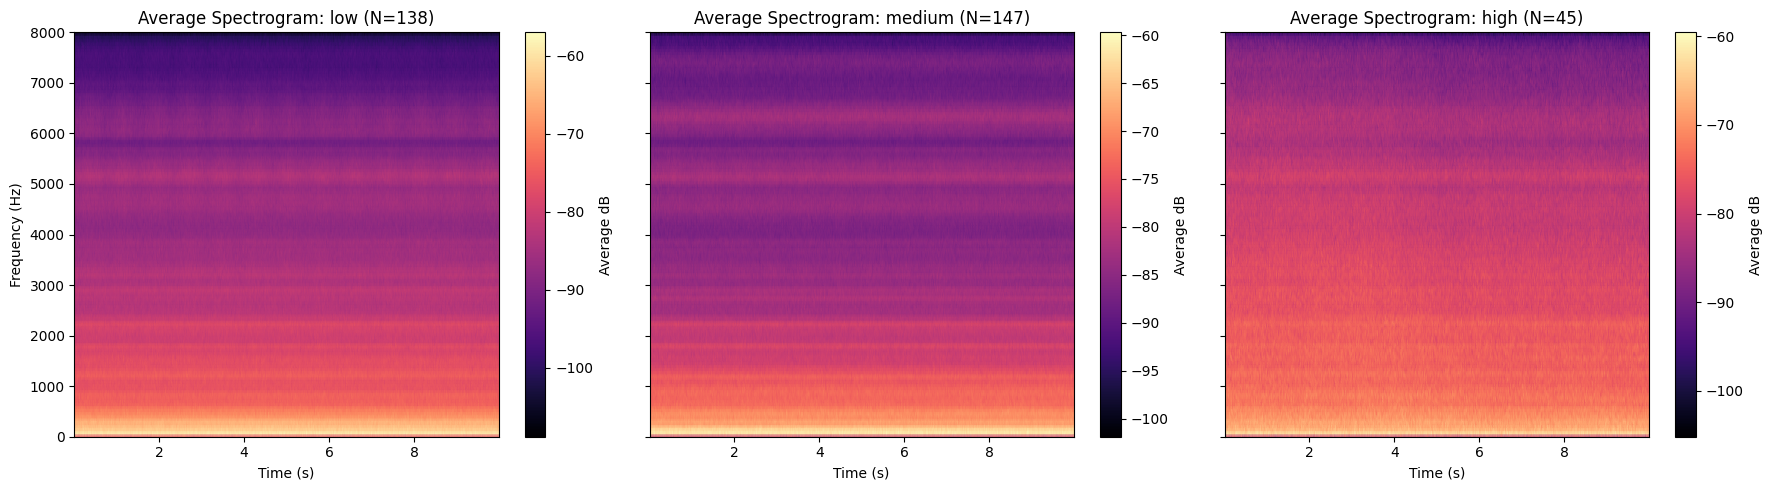

In [4]:
plot_average_spectrograms(train_audio_dict, 
                          sr=sample_rate, 
                          save_path="results/figures/average_spectograms_plot.png",
                          dpi=300)

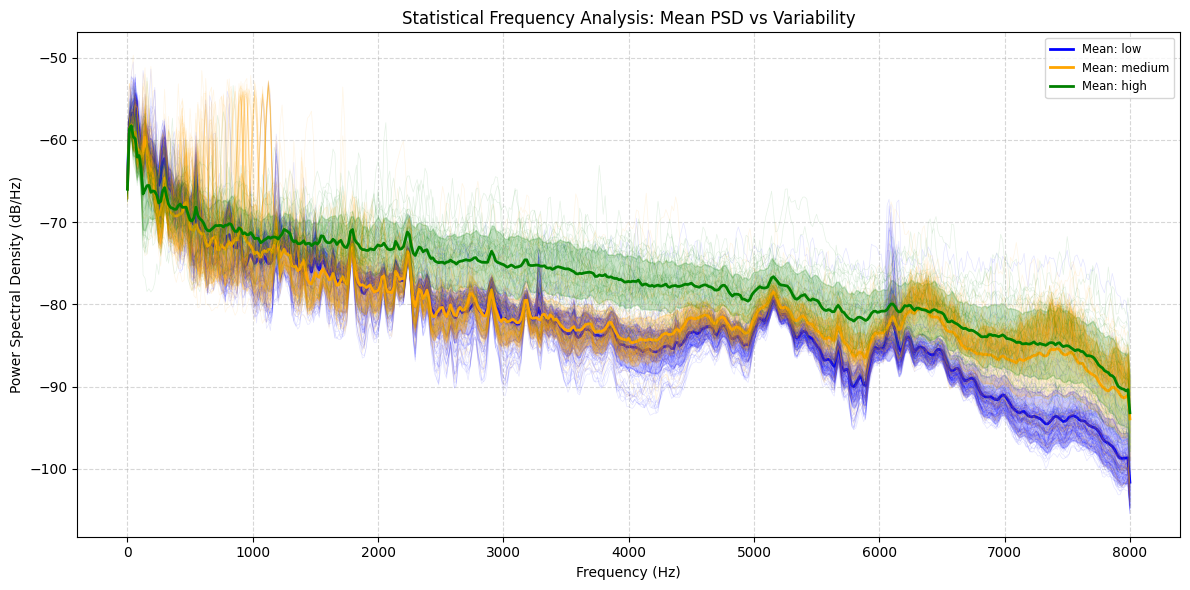

In [5]:
full_noise_profiles_plot(train_audio_dict, 
                         sr=sample_rate,
                         save_path="results/figures/full_noise_profiles_plot.png",
                         dpi=300)                          

In [6]:
eda_final_detailed = get_detailed_eda_df(train_audio_dict, 
                                         save_path="results/tables/eda_metrics.csv",
                                         )



display(eda_final_detailed)

,RMS_mean,RMS_std,CF_mean,CF_std,Kurtosis_mean,Kurtosis_std
Noise Category,,,,,,
low,0.021909,0.000248,4.720846,1.100903,0.264599,2.550621
medium,0.021951,0.000369,4.752227,0.839527,0.120833,0.630545
high,0.021885,0.000220,5.288807,0.924750,0.248611,0.354576


### signal pre processing:

In [7]:
train_data_processed = apply_envelope_pipeline_to_audio_dict(
    train_audio_dict, low=low, high=high, cutoff=cutoff,
    sr=sample_rate
)

test_data_processed = apply_envelope_pipeline_to_audio_dict(
    test_audio_dict, low=low, high=high, cutoff=cutoff,
    sr=sample_rate
)

Plot saved to: results/figures/filter_results_plots.png


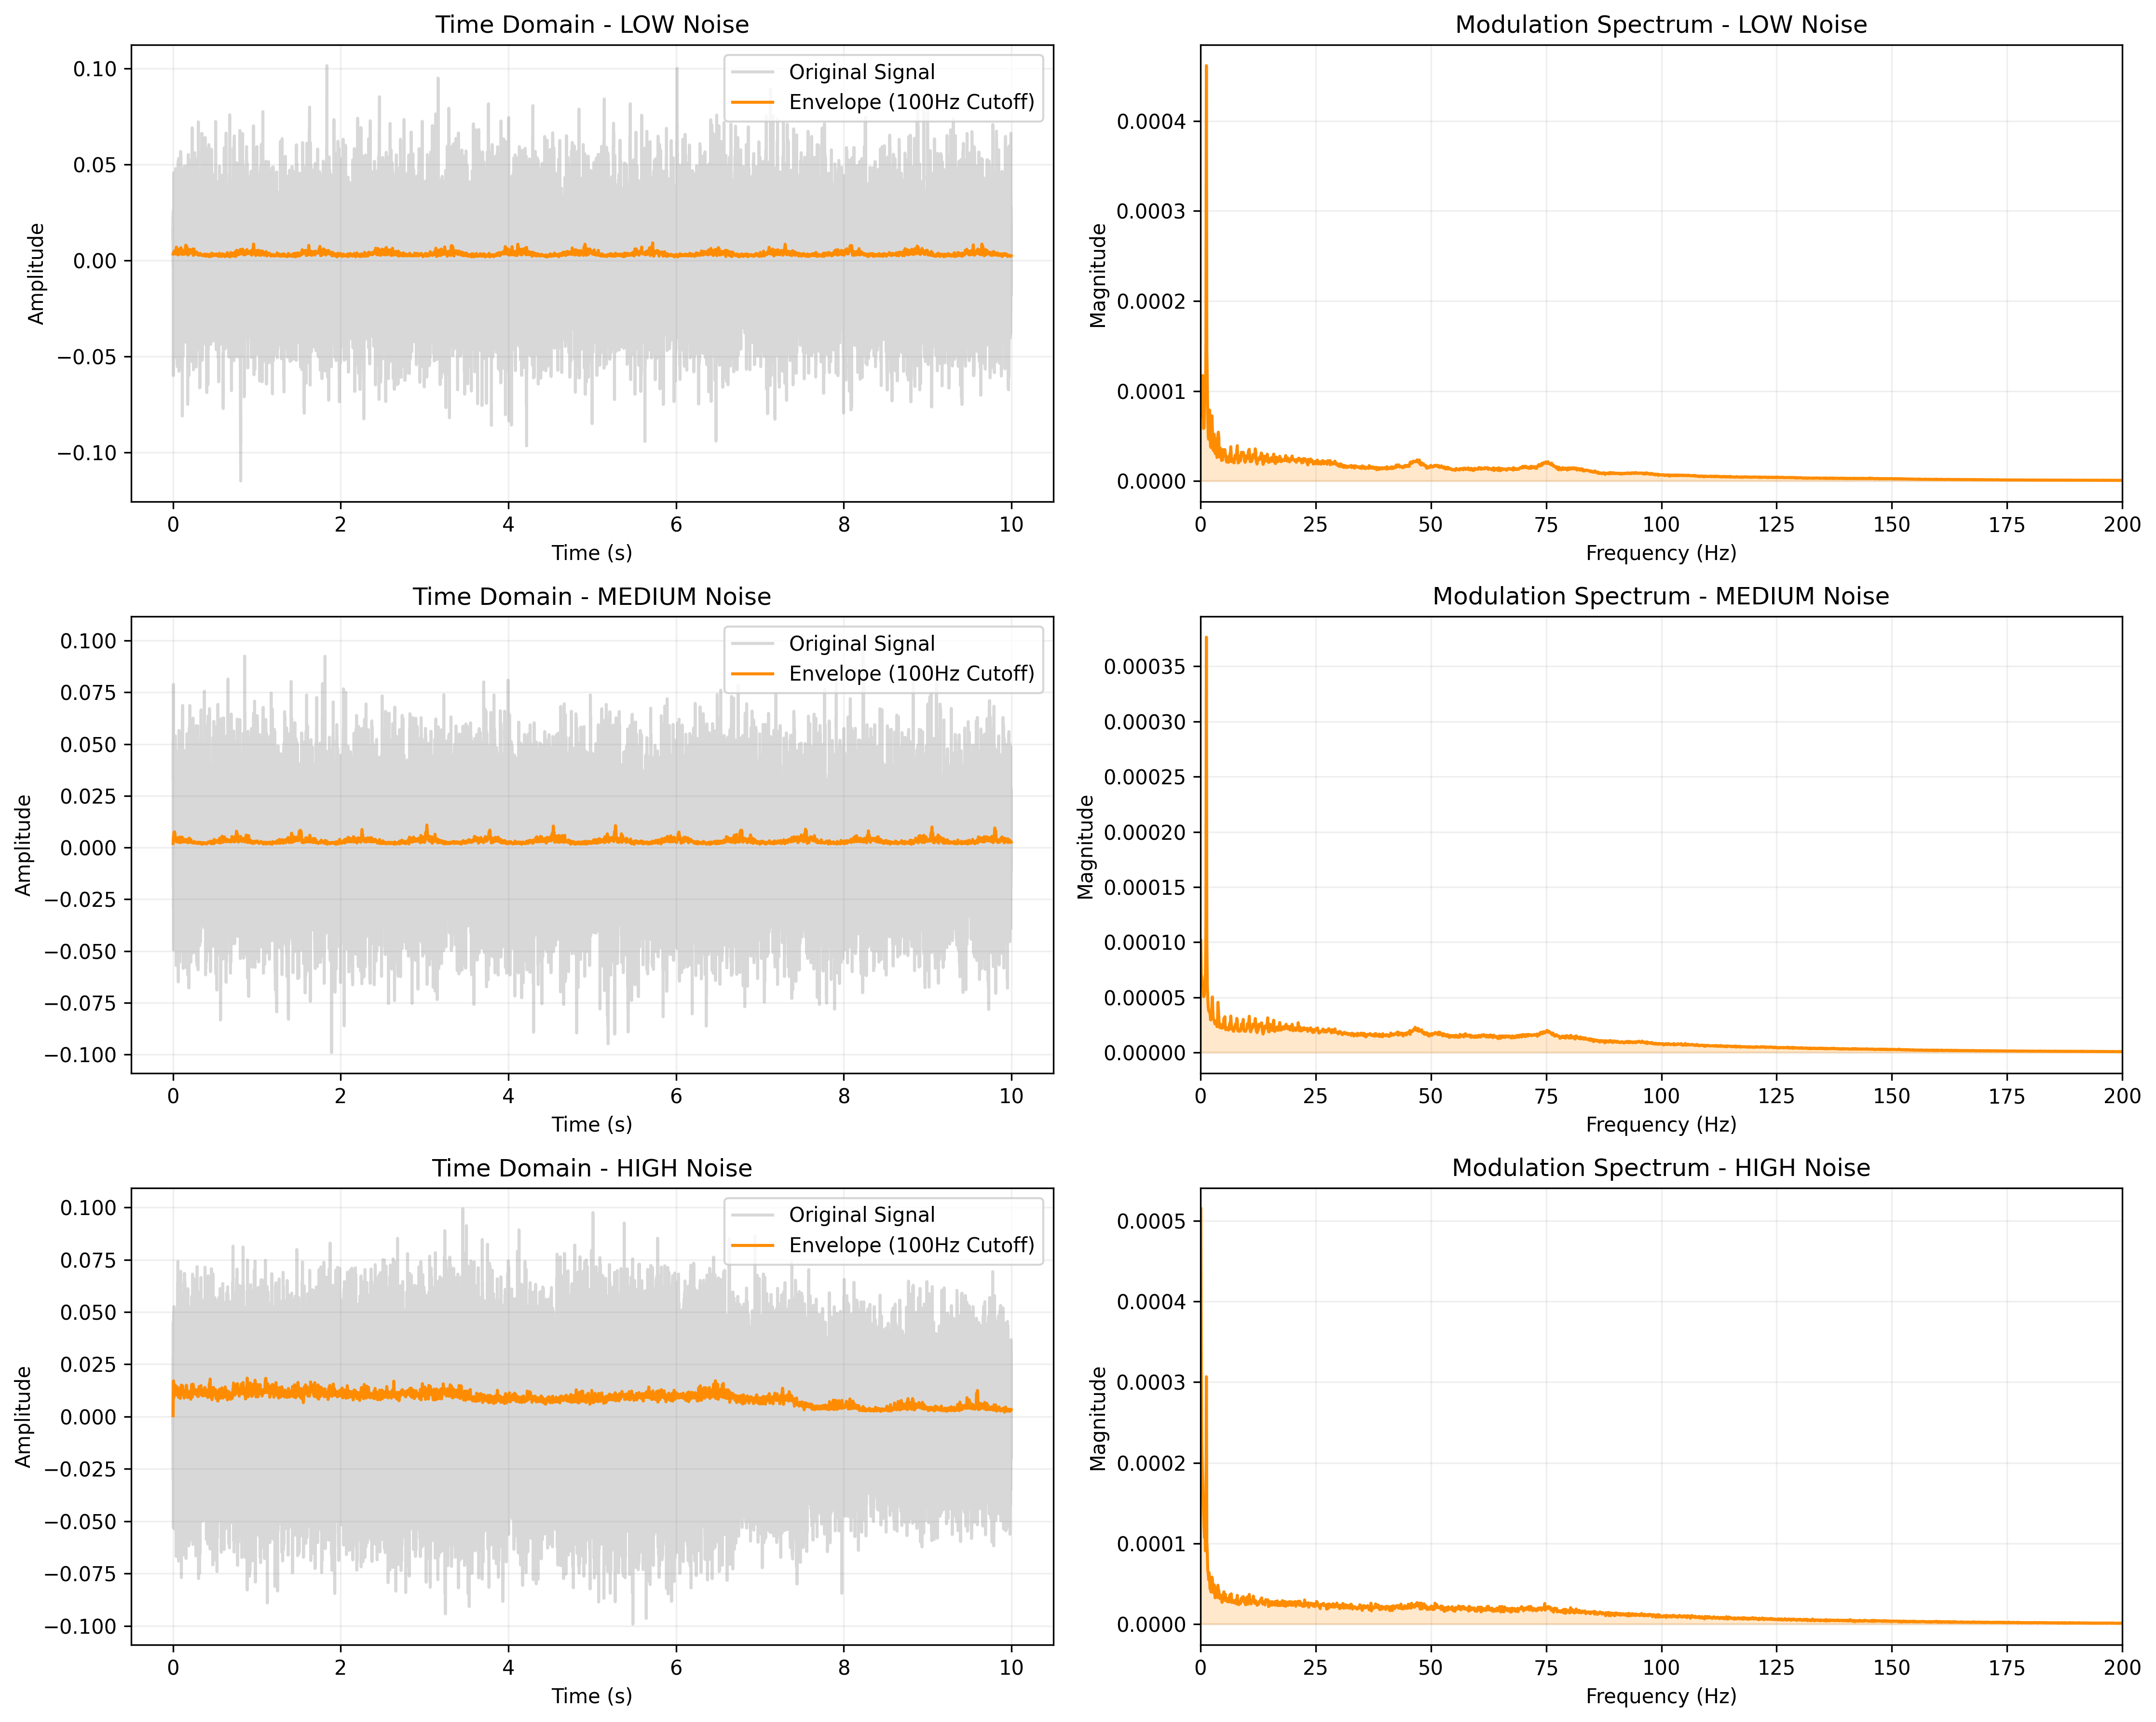

In [ ]:
groups = {"low": [], "medium": [], "high": []}

for key in train_audio_dict.keys():
    k = key.lower()

    before = train_audio_dict[key]
    after = train_data_processed[key]

    if "low" in k:
        groups["low"].append((before, after))
    elif "medium" in k:
        groups["medium"].append((before, after))
    elif "high" in k:
        groups["high"].append((before, after))


plot_envelope_analysis(groups, sample_rate, cutoff, 
                       save_path="results/figures/filter_results_plots.png")

### modeling PCA reconstruction - pipeline:

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

train_set = extract_target_and_features(audio_dict=train_data_processed, sr=sample_rate)
test_set = extract_target_and_features(audio_dict=test_data_processed, sr=sample_rate)

x_train = train_set.drop(columns=["anomaly"])
y_train = train_set[["anomaly"]]
x_test = test_set.drop(columns=["anomaly"])
y_test = test_set[["anomaly"]]

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

pca = PCA(n_components=n_components)
pca.fit(x_train_scaled)

X_train_recon = pca.inverse_transform(pca.transform(x_train_scaled))
train_errors = np.mean((x_train_scaled - X_train_recon)**2, axis=1)

X_test_recon = pca.inverse_transform(pca.transform(x_test_scaled))
test_errors = np.mean((x_test_scaled - X_test_recon)**2, axis=1)

### results:

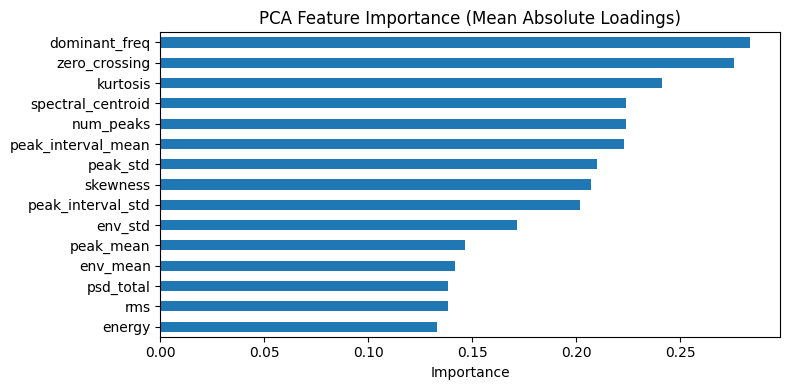

In [10]:
importance = plot_pca_feature_importance(
    pca,
    x_train,
    save_path="results/figures/pca_feature_importance.png",
    dpi=300
)

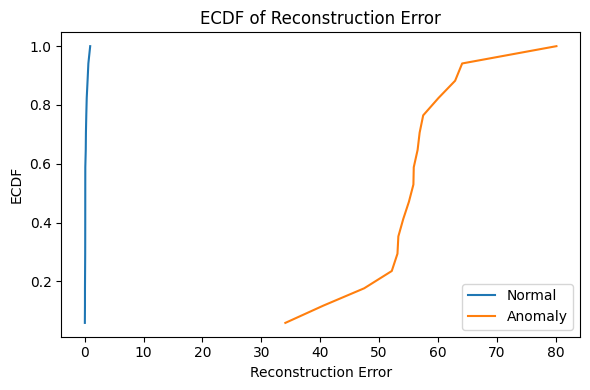

In [11]:
plot_ecdf_anomaly_detection(test_errors, y_test,
                            save_path="results/figures/ecdf_plot.png",
                            dpi=300)

In [12]:
evaluate_and_save_metrics(test_errors, y_test,
                          threshold=1.0,
                          save_path="results/tables/metrics.csv",
                          model_name="pca_reconstruction")

,model,auc,precision,recall,f1
0,pca_reconstruction,1.0,1.0,1.0,1.0


___